# ATAC-informed analysis and visualization

This notebook keeps one final implementation for each distinct analysis figure. Repeated revisions of colors, titles, labels, dimensions, and annotations have been removed.

Each visualization cell reloads its own input data and uses uniquely named variables. This prevents hidden state from an earlier cell from changing the behavior of a later cell.

Retained analyses:

1. Functional-region attribution
2. Representative gene-level region profiles
3. Promoter peak-masking ablation
4. ATAC-corrected response-gene heatmap
5. Pathway-enrichment dot plot
6. Region-gene-program mechanism network
7. ATAC guidance-strength ablation
8. Fine-grained peak-level attribution
9. Method comparison
10. RNA-only versus RNA+ATAC comparison


In [1]:
from pathlib import Path
import re
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


ROOT = Path("/root/autodl-tmp/scERso")
MULTIPERTURB_DIR = ROOT / "multiperturb_seq"
BASE_DIR = (
    MULTIPERTURB_DIR
    / "atac_functional_attribution_GRCh38"
)
OUTPUT_DIR = BASE_DIR / "figures_deduplicated_runnable"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PAPER_COLORS = {
    "rose": "#C98C93",
    "red": "#C65B67",
    "blue": "#7AA6C9",
    "teal": "#69B7BE",
    "orange": "#E6B06A",
    "gray": "#BDBDBD",
    "dark": "#4A4A4A",
}

COLOR_PAIRS = {
    "rose": {
        "dark": "#8F1F22",
        "light": "#BF888E",
    },
    "blue": {
        "dark": "#004E85",
        "light": "#7EA4C2",
    },
    "teal": {
        "dark": "#107A83",
        "light": "#7DB7BE",
    },
}

REGION_ORDER = [
    "promoter",
    "gene_body",
    "distal",
]

REGION_LABELS = {
    "promoter": "Promoter",
    "gene_body": "Gene body",
    "distal": "Distal",
}

REGION_COLORS = {
    "promoter": "#4C78A8",
    "gene_body": "#72B7B2",
    "distal": "#F58518",
}

DELTA_CMAP = LinearSegmentedColormap.from_list(
    "delta_blue_white_rose",
    [
        COLOR_PAIRS["blue"]["dark"],
        COLOR_PAIRS["blue"]["light"],
        "#F7F7F7",
        COLOR_PAIRS["rose"]["light"],
        COLOR_PAIRS["rose"]["dark"],
    ],
    N=256,
)

PATHWAY_CMAP = LinearSegmentedColormap.from_list(
    "pathway_teal",
    [
        "#F7F7F7",
        COLOR_PAIRS["teal"]["light"],
        COLOR_PAIRS["teal"]["dark"],
    ],
    N=256,
)

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Arial",
            "DejaVu Sans",
        ],
        "font.size": 8.5,
        "axes.titlesize": 10,
        "axes.titleweight": "normal",
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
)


def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Required file does not exist: {path}"
        )
    return path


def require_columns(dataframe, columns, table_name):
    missing = set(columns).difference(dataframe.columns)
    if missing:
        raise ValueError(
            f"{table_name} is missing required columns: "
            + ", ".join(sorted(missing))
            + f". Available columns: {dataframe.columns.tolist()}"
        )


def save_figure(figure, output_prefix):
    output_prefix = Path(output_prefix)
    output_prefix.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    for extension in (
        "png",
        "svg",
        "pdf",
    ):
        output_file = output_prefix.with_suffix(
            f".{extension}"
        )
        figure.savefig(
            output_file,
            bbox_inches="tight",
            pad_inches=0.05,
        )
        print(f"Saved figure: {output_file}")


def make_unique_labels(labels):
    counts = {}
    unique_labels = []

    for label in labels:
        label = str(label)
        counts[label] = counts.get(label, 0) + 1

        if counts[label] == 1:
            unique_labels.append(label)
        else:
            unique_labels.append(
                f"{label}_{counts[label]}"
            )

    return unique_labels


def clean_pathway_term(term, max_length=90):
    text = str(term)
    text = re.sub(
        r"\s+R-HSA-\d+$",
        "",
        text,
    )
    text = re.sub(
        r"\s+\(GO:\d+\)$",
        "",
        text,
    )

    if len(text) > max_length:
        text = text[: max_length - 3] + "..."

    return text


Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/functional_region_attribution.png
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/functional_region_attribution.svg
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/functional_region_attribution.pdf


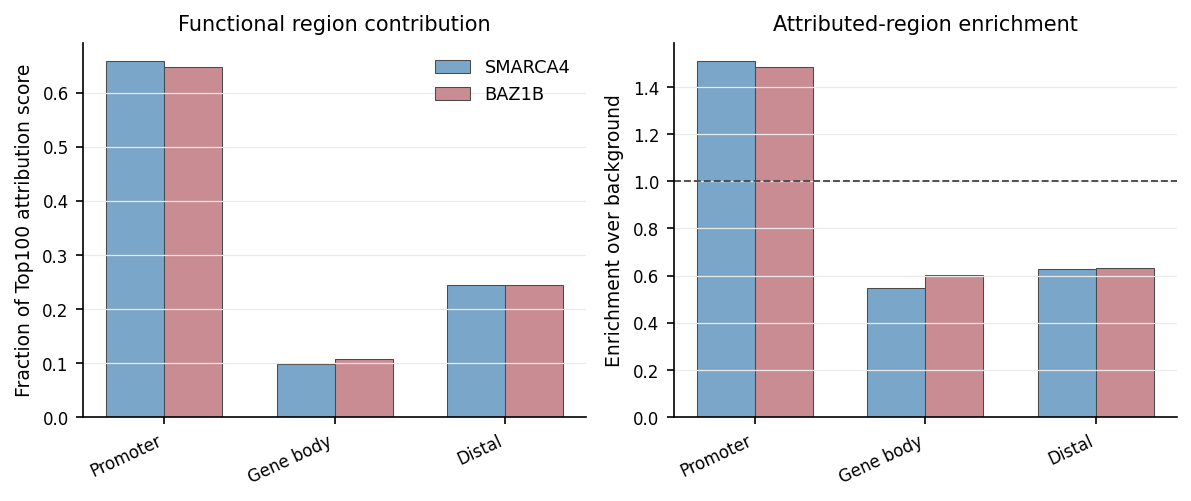

In [2]:
# Functional-region attribution

region_summary_path = require_file(
    BASE_DIR
    / "functional_region_attribution"
    / "SMARCA4_BAZ1B_functional_region_attribution_summary.csv"
)

region_summary = pd.read_csv(
    region_summary_path
)

require_columns(
    region_summary,
    [
        "perturbation",
        "region_class",
        "top100_score_fraction",
        "top100_score_fraction_enrichment",
    ],
    "Functional-region attribution summary",
)

region_summary = region_summary[
    region_summary["region_class"].isin(
        REGION_ORDER
    )
].copy()

cases = [
    case
    for case in [
        "SMARCA4",
        "BAZ1B",
    ]
    if case
    in set(
        region_summary["perturbation"]
    )
]

figure, axes = plt.subplots(
    1,
    2,
    figsize=(8.0, 3.4),
)

x_positions = np.arange(
    len(REGION_ORDER)
)
bar_width = 0.34

for case_index, case in enumerate(cases):
    case_data = (
        region_summary[
            region_summary["perturbation"]
            == case
        ]
        .set_index("region_class")
        .reindex(REGION_ORDER)
    )

    offset = (
        case_index
        - (len(cases) - 1) / 2
    ) * bar_width

    axes[0].bar(
        x_positions + offset,
        case_data[
            "top100_score_fraction"
        ],
        width=bar_width,
        label=case,
        color=(
            PAPER_COLORS["blue"]
            if case == "SMARCA4"
            else PAPER_COLORS["rose"]
        ),
        edgecolor=PAPER_COLORS["dark"],
        linewidth=0.5,
    )

    axes[1].bar(
        x_positions + offset,
        case_data[
            "top100_score_fraction_enrichment"
        ],
        width=bar_width,
        label=case,
        color=(
            PAPER_COLORS["blue"]
            if case == "SMARCA4"
            else PAPER_COLORS["rose"]
        ),
        edgecolor=PAPER_COLORS["dark"],
        linewidth=0.5,
    )

axes[0].set_ylabel(
    "Fraction of Top100 attribution score"
)
axes[0].set_title(
    "Functional region contribution"
)

axes[1].axhline(
    1.0,
    color=PAPER_COLORS["dark"],
    linestyle="--",
    linewidth=0.9,
)
axes[1].set_ylabel(
    "Enrichment over background"
)
axes[1].set_title(
    "Attributed-region enrichment"
)

for axis in axes:
    axis.set_xticks(x_positions)
    axis.set_xticklabels(
        [
            REGION_LABELS[region]
            for region in REGION_ORDER
        ],
        rotation=25,
        ha="right",
    )
    axis.grid(
        axis="y",
        color="#EAEAEA",
        linewidth=0.6,
    )

axes[0].legend(
    frameon=False,
)

figure.tight_layout()

save_figure(
    figure,
    OUTPUT_DIR
    / "functional_region_attribution",
)

plt.show()


Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/representative_gene_region_profiles.png
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/representative_gene_region_profiles.svg
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/representative_gene_region_profiles.pdf


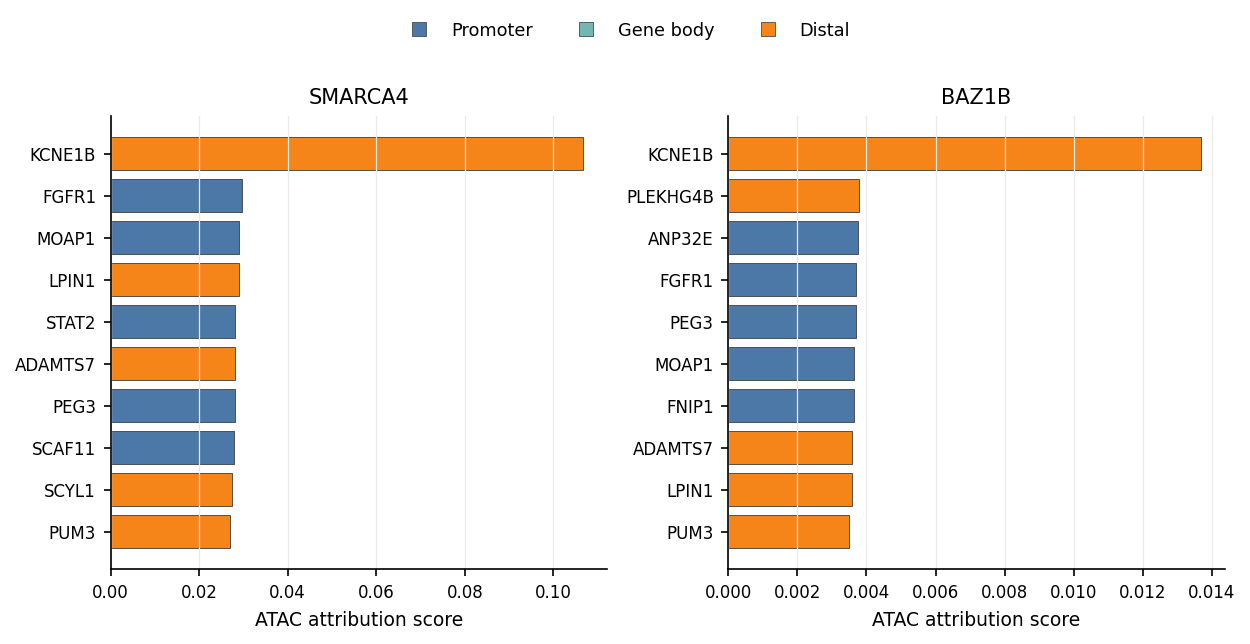

In [3]:
# Representative gene-level region profiles

representative_path = (
    BASE_DIR
    / "functional_region_attribution"
    / "SMARCA4_BAZ1B_representative_two_region_gene_cases.csv"
)

if representative_path.exists():
    representative_data = pd.read_csv(
        representative_path
    )
else:
    top100_path = require_file(
        BASE_DIR
        / "peak_gene_annotation"
        / "SMARCA4_BAZ1B_top100_peak_nearest_gene_annotation_combined.csv"
    )

    top100_data = pd.read_csv(
        top100_path
    )

    require_columns(
        top100_data,
        [
            "perturbation",
            "nearest_gene",
            "region_class",
            "peak_abs_score",
        ],
        "Top100 peak annotation",
    )

    top100_data["peak_abs_score"] = (
        pd.to_numeric(
            top100_data["peak_abs_score"],
            errors="coerce",
        )
        .fillna(0.0)
    )

    gene_region_long = (
        top100_data
        .groupby(
            [
                "perturbation",
                "nearest_gene",
                "region_class",
            ],
            as_index=False,
        )
        .agg(
            region_abs_score=(
                "peak_abs_score",
                "sum",
            ),
            n_peaks=(
                "peak_abs_score",
                "size",
            ),
        )
    )

    representative_rows = []

    for case in [
        "SMARCA4",
        "BAZ1B",
    ]:
        case_data = gene_region_long[
            gene_region_long[
                "perturbation"
            ]
            == case
        ].copy()

        promoter_rows = (
            case_data[
                case_data["region_class"]
                == "promoter"
            ]
            .sort_values(
                "region_abs_score",
                ascending=False,
            )
            .head(5)
        )

        non_promoter_rows = (
            case_data[
                case_data["region_class"].isin(
                    [
                        "gene_body",
                        "distal",
                    ]
                )
            ]
            .sort_values(
                "region_abs_score",
                ascending=False,
            )
            .head(5)
        )

        representative_rows.extend(
            [
                promoter_rows,
                non_promoter_rows,
            ]
        )

    representative_data = pd.concat(
        representative_rows,
        ignore_index=True,
    )

require_columns(
    representative_data,
    [
        "perturbation",
        "nearest_gene",
    ],
    "Representative gene-region table",
)

if "region_abs_score" not in representative_data.columns:
    if "total_abs_score" in representative_data.columns:
        representative_data[
            "region_abs_score"
        ] = representative_data[
            "total_abs_score"
        ]
    else:
        raise ValueError(
            "Representative gene-region table "
            "must contain region_abs_score "
            "or total_abs_score."
        )

if "region_class" not in representative_data.columns:
    if "dominant_region" in representative_data.columns:
        representative_data[
            "region_class"
        ] = representative_data[
            "dominant_region"
        ]
    else:
        raise ValueError(
            "Representative gene-region table "
            "must contain region_class "
            "or dominant_region."
        )

figure, axes = plt.subplots(
    1,
    2,
    figsize=(8.4, 4.2),
)

for axis, case in zip(
    axes,
    [
        "SMARCA4",
        "BAZ1B",
    ],
):
    case_data = (
        representative_data[
            representative_data[
                "perturbation"
            ]
            == case
        ]
        .sort_values(
            "region_abs_score",
            ascending=True,
        )
        .copy()
    )

    y_positions = np.arange(
        len(case_data)
    )

    axis.barh(
        y_positions,
        case_data[
            "region_abs_score"
        ],
        color=[
            REGION_COLORS.get(
                region,
                PAPER_COLORS["gray"],
            )
            for region in case_data[
                "region_class"
            ]
        ],
        edgecolor=PAPER_COLORS["dark"],
        linewidth=0.45,
    )

    axis.set_yticks(y_positions)
    axis.set_yticklabels(
        case_data["nearest_gene"]
    )
    axis.set_xlabel(
        "ATAC attribution score"
    )
    axis.set_title(case)
    axis.grid(
        axis="x",
        color="#EAEAEA",
        linewidth=0.6,
    )

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markerfacecolor=REGION_COLORS[region],
        markeredgecolor=PAPER_COLORS["dark"],
        markeredgewidth=0.4,
        label=REGION_LABELS[region],
        markersize=7,
    )
    for region in REGION_ORDER
]

figure.legend(
    handles=legend_handles,
    frameon=False,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
)

figure.tight_layout(
    rect=[0, 0, 1, 0.92]
)

save_figure(
    figure,
    OUTPUT_DIR
    / "representative_gene_region_profiles",
)

plt.show()


Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/promoter_peak_masking_ablation.png
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/promoter_peak_masking_ablation.svg
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/promoter_peak_masking_ablation.pdf


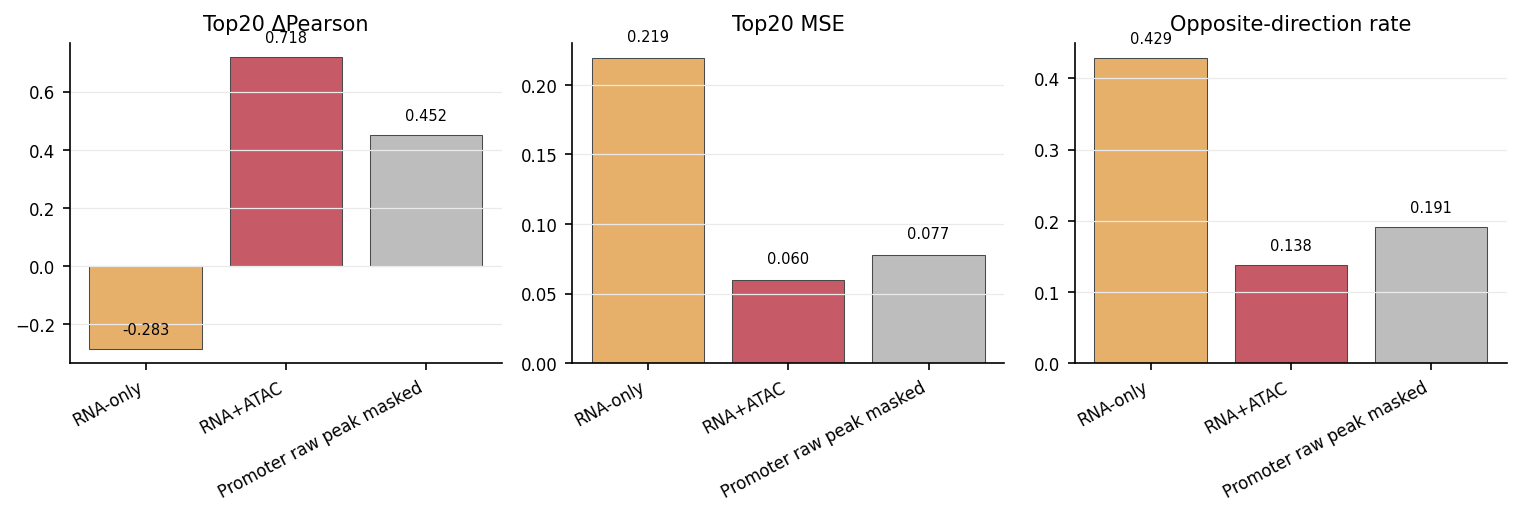

In [4]:
# Promoter peak-masking ablation

ablation_path = require_file(
    BASE_DIR
    / "region_ablation_summary"
    / "RNA_ATAC_promoter_raw_ablation_metric_summary_3models.csv"
)

ablation_metrics = pd.read_csv(
    ablation_path
)

require_columns(
    ablation_metrics,
    [
        "model",
        "perturb_top20_delta_pearson",
        "perturb_top20_mse",
        "perturb_top20_opposite_direction",
    ],
    "Promoter peak-masking summary",
)

model_order = [
    "RNA-only",
    "RNA+ATAC",
    "Promoter raw peak masked",
]

model_colors = {
    "RNA-only": PAPER_COLORS["orange"],
    "RNA+ATAC": PAPER_COLORS["red"],
    "Promoter raw peak masked": PAPER_COLORS["gray"],
}

ablation_metrics["model"] = pd.Categorical(
    ablation_metrics["model"],
    categories=model_order,
    ordered=True,
)

ablation_metrics = (
    ablation_metrics
    .sort_values("model")
    .reset_index(drop=True)
)

metric_specs = [
    (
        "perturb_top20_delta_pearson",
        "Top20 ΔPearson",
    ),
    (
        "perturb_top20_mse",
        "Top20 MSE",
    ),
    (
        "perturb_top20_opposite_direction",
        "Opposite-direction rate",
    ),
]

figure, axes = plt.subplots(
    1,
    3,
    figsize=(10.2, 3.5),
)

for axis, (
    metric_column,
    title,
) in zip(
    axes,
    metric_specs,
):
    values = ablation_metrics[
        metric_column
    ].astype(float)

    bars = axis.bar(
        np.arange(
            len(ablation_metrics)
        ),
        values,
        color=[
            model_colors[str(model)]
            for model in ablation_metrics[
                "model"
            ]
        ],
        edgecolor=PAPER_COLORS["dark"],
        linewidth=0.5,
    )

    axis.set_xticks(
        np.arange(
            len(ablation_metrics)
        )
    )
    axis.set_xticklabels(
        ablation_metrics["model"],
        rotation=28,
        ha="right",
    )
    axis.set_title(title)
    axis.grid(
        axis="y",
        color="#EAEAEA",
        linewidth=0.6,
    )

    value_range = (
        float(values.max())
        - float(values.min())
    )
    offset = max(
        0.01,
        0.04 * max(
            value_range,
            abs(float(values.max())),
        ),
    )

    for bar, value in zip(
        bars,
        values,
    ):
        axis.text(
            bar.get_x()
            + bar.get_width() / 2,
            value + offset,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

figure.tight_layout()

save_figure(
    figure,
    OUTPUT_DIR
    / "promoter_peak_masking_ablation",
)

plt.show()


Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/atac_corrected_gene_heatmap.png
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/atac_corrected_gene_heatmap.svg
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/atac_corrected_gene_heatmap.pdf


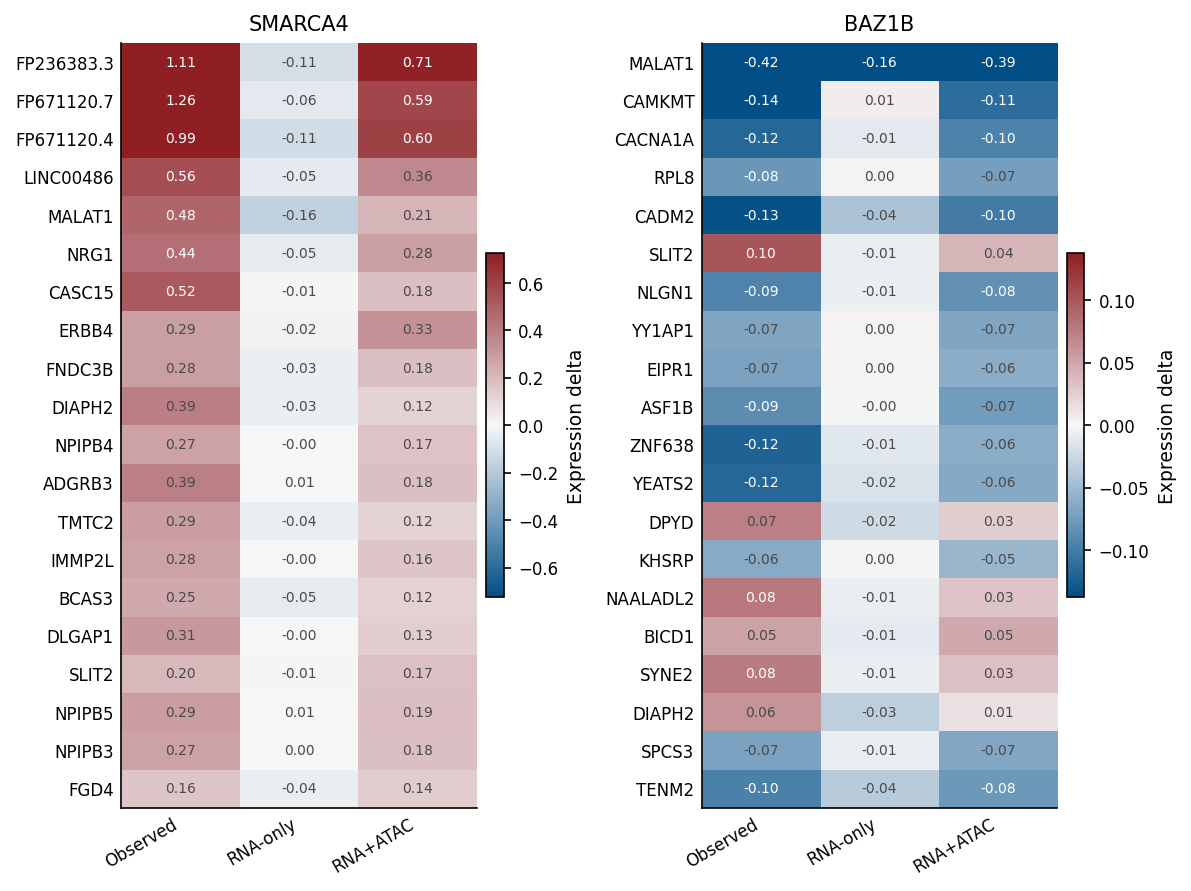

In [5]:
# ATAC-corrected response-gene heatmap

enrichment_dir = (
    BASE_DIR
    / "atac_corrected_genes_pathway_enrichment"
)

cases = [
    "SMARCA4",
    "BAZ1B",
]
top_heatmap_n = 20

corrected_tables = {}

for case in cases:
    corrected_path = require_file(
        enrichment_dir
        / f"{case}_ATAC_corrected_genes_top_annotated.csv"
    )

    corrected_table = pd.read_csv(
        corrected_path
    )

    require_columns(
        corrected_table,
        [
            "gene",
            "true_delta",
            "rna_only_delta",
            "rna_atac_delta",
            "corrected_score",
        ],
        f"{case} corrected-gene table",
    )

    corrected_tables[case] = (
        corrected_table
        .sort_values(
            "corrected_score",
            ascending=False,
        )
        .head(top_heatmap_n)
        .copy()
    )

figure, axes = plt.subplots(
    1,
    2,
    figsize=(8.0, 6.0),
)

for axis, case in zip(
    axes,
    cases,
):
    corrected_table = corrected_tables[
        case
    ]

    if (
        "gene_symbol"
        in corrected_table.columns
    ):
        gene_labels = (
            corrected_table[
                "gene_symbol"
            ]
            .fillna(
                corrected_table["gene"]
            )
            .astype(str)
            .tolist()
        )
    else:
        gene_labels = (
            corrected_table["gene"]
            .astype(str)
            .tolist()
        )

    gene_labels = make_unique_labels(
        gene_labels
    )

    matrix = corrected_table[
        [
            "true_delta",
            "rna_only_delta",
            "rna_atac_delta",
        ]
    ].to_numpy(dtype=float)

    value_limit = float(
        np.nanpercentile(
            np.abs(matrix),
            95,
        )
    )

    if (
        not np.isfinite(value_limit)
        or value_limit <= 0
    ):
        value_limit = (
            float(
                np.nanmax(
                    np.abs(matrix)
                )
            )
            + 1e-8
        )

    image = axis.imshow(
        matrix,
        aspect="auto",
        cmap=DELTA_CMAP,
        vmin=-value_limit,
        vmax=value_limit,
        interpolation="nearest",
    )

    axis.set_xticks(
        [
            0,
            1,
            2,
        ]
    )
    axis.set_xticklabels(
        [
            "Observed",
            "RNA-only",
            "RNA+ATAC",
        ],
        rotation=30,
        ha="right",
    )
    axis.set_yticks(
        np.arange(
            len(gene_labels)
        )
    )
    axis.set_yticklabels(
        gene_labels
    )
    axis.set_title(case)
    axis.tick_params(
        axis="both",
        length=0,
    )

    for row_index in range(
        matrix.shape[0]
    ):
        for column_index in range(
            matrix.shape[1]
        ):
            value = matrix[
                row_index,
                column_index,
            ]

            text_color = (
                "white"
                if abs(value)
                > 0.55 * value_limit
                else PAPER_COLORS["dark"]
            )

            axis.text(
                column_index,
                row_index,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=6.7,
                color=text_color,
            )

    colorbar = figure.colorbar(
        image,
        ax=axis,
        fraction=0.045,
        pad=0.025,
    )
    colorbar.set_label(
        "Expression delta"
    )

figure.tight_layout()

save_figure(
    figure,
    OUTPUT_DIR
    / "atac_corrected_gene_heatmap",
)

plt.show()


Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/pathway_enrichment_dotplot.png
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/pathway_enrichment_dotplot.svg
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/pathway_enrichment_dotplot.pdf


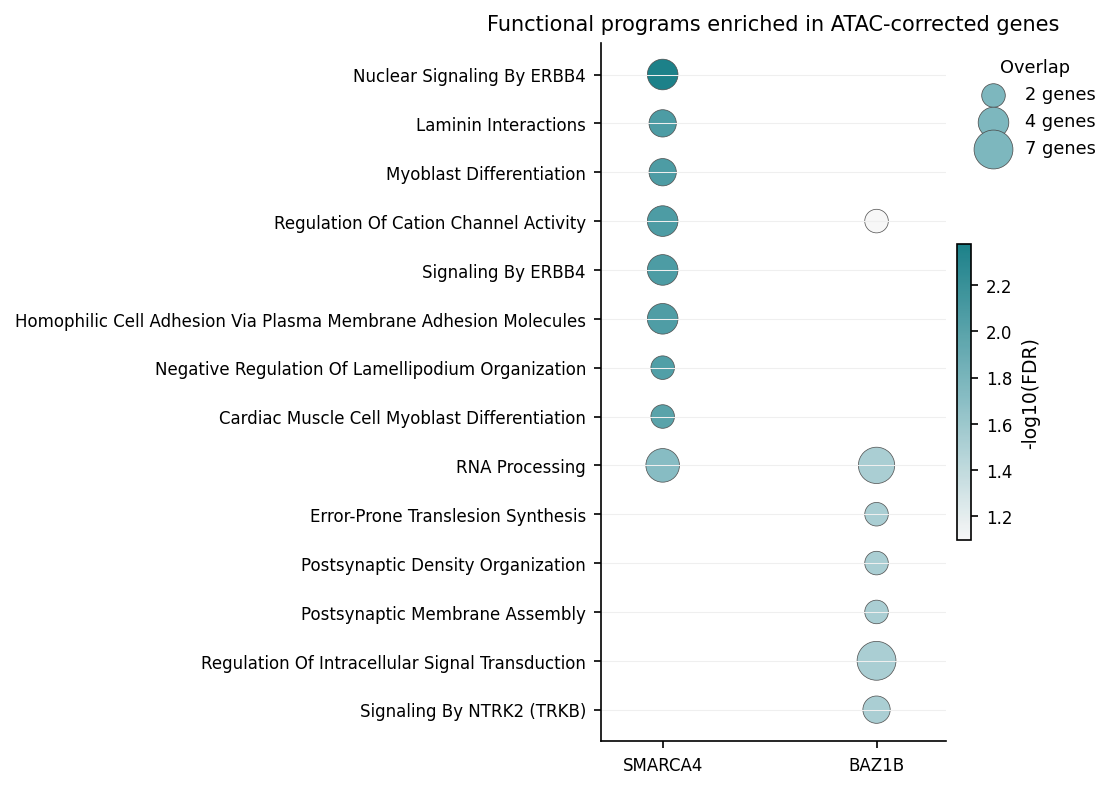

In [6]:
# Pathway-enrichment dot plot

enrichment_dir = (
    BASE_DIR
    / "atac_corrected_genes_pathway_enrichment"
)

top_n = 100

smarca4_path = require_file(
    enrichment_dir
    / f"SMARCA4_ATAC_corrected_Top{top_n}_offline_pathway_enrichment.csv"
)
baz1b_path = require_file(
    enrichment_dir
    / f"BAZ1B_ATAC_corrected_Top{top_n}_offline_pathway_enrichment.csv"
)

smarca4_enrichment = pd.read_csv(
    smarca4_path
)
baz1b_enrichment = pd.read_csv(
    baz1b_path
)

required_enrichment_columns = [
    "term",
    "fdr",
    "p_value",
    "overlap_size",
    "minus_log10_fdr",
]

require_columns(
    smarca4_enrichment,
    required_enrichment_columns,
    "SMARCA4 enrichment table",
)
require_columns(
    baz1b_enrichment,
    required_enrichment_columns,
    "BAZ1B enrichment table",
)

selected_terms = []

selected_terms.extend(
    smarca4_enrichment
    .sort_values(
        [
            "fdr",
            "p_value",
        ]
    )
    .query("fdr < 0.10")
    .head(8)["term"]
    .tolist()
)

selected_terms.extend(
    baz1b_enrichment
    .sort_values(
        [
            "fdr",
            "p_value",
        ]
    )
    .head(6)["term"]
    .tolist()
)

selected_terms = list(
    dict.fromkeys(
        selected_terms
    )
)

dotplot_parts = []

for case, table in [
    (
        "SMARCA4",
        smarca4_enrichment,
    ),
    (
        "BAZ1B",
        baz1b_enrichment,
    ),
]:
    subset = table[
        table["term"].isin(
            selected_terms
        )
    ].copy()

    subset["perturbation"] = case
    dotplot_parts.append(subset)

dotplot_data = pd.concat(
    dotplot_parts,
    ignore_index=True,
)

dotplot_data = (
    dotplot_data
    .replace(
        [
            np.inf,
            -np.inf,
        ],
        np.nan,
    )
    .dropna(
        subset=[
            "fdr",
            "p_value",
            "overlap_size",
            "minus_log10_fdr",
        ]
    )
    .copy()
)

term_order = (
    dotplot_data
    .groupby("term")["fdr"]
    .min()
    .sort_values(
        ascending=True
    )
    .index
    .tolist()[::-1]
)

x_positions = {
    "SMARCA4": 0.0,
    "BAZ1B": 1.55,
}

y_positions = {
    term: index
    for index, term in enumerate(
        term_order
    )
}

dotplot_data["x"] = (
    dotplot_data[
        "perturbation"
    ].map(x_positions)
)
dotplot_data["y"] = (
    dotplot_data["term"].map(
        y_positions
    )
)

point_sizes = (
    40
    + 44
    * dotplot_data[
        "overlap_size"
    ].astype(float)
)

color_values = dotplot_data[
    "minus_log10_fdr"
].astype(float)

normalizer = Normalize(
    vmin=float(
        color_values.min()
    ),
    vmax=float(
        color_values.max()
    ),
)

figure_height = max(
    4.8,
    0.38 * len(term_order),
)

figure, axis = plt.subplots(
    figsize=(
        7.4,
        figure_height,
    )
)

scatter = axis.scatter(
    dotplot_data["x"],
    dotplot_data["y"],
    s=point_sizes,
    c=color_values,
    cmap=PATHWAY_CMAP,
    norm=normalizer,
    alpha=0.95,
    edgecolor=PAPER_COLORS["dark"],
    linewidth=0.35,
)

axis.set_xticks(
    list(
        x_positions.values()
    )
)
axis.set_xticklabels(
    list(
        x_positions.keys()
    )
)
axis.set_yticks(
    np.arange(
        len(term_order)
    )
)
axis.set_yticklabels(
    [
        clean_pathway_term(term)
        for term in term_order
    ]
)
axis.set_xlim(
    -0.45,
    2.05,
)
axis.set_title(
    "Functional programs enriched in ATAC-corrected genes"
)
axis.grid(
    axis="y",
    color="#EFEFEF",
    linewidth=0.5,
)

colorbar = figure.colorbar(
    scatter,
    ax=axis,
    fraction=0.04,
    pad=0.03,
)
colorbar.set_label(
    "-log10(FDR)"
)

legend_values = [
    2,
    4,
    7,
]

size_handles = [
    axis.scatter(
        [],
        [],
        s=40 + 44 * value,
        color=COLOR_PAIRS[
            "teal"
        ]["light"],
        edgecolor=PAPER_COLORS[
            "dark"
        ],
        linewidth=0.35,
        label=f"{value} genes",
    )
    for value in legend_values
]

axis.legend(
    handles=size_handles,
    title="Overlap",
    frameon=False,
    bbox_to_anchor=(
        1.04,
        1.0,
    ),
    loc="upper left",
)

figure.tight_layout()

save_figure(
    figure,
    OUTPUT_DIR
    / "pathway_enrichment_dotplot",
)

plt.show()


Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/smarca4_region_gene_program_network.png
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/smarca4_region_gene_program_network.svg
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/smarca4_region_gene_program_network.pdf


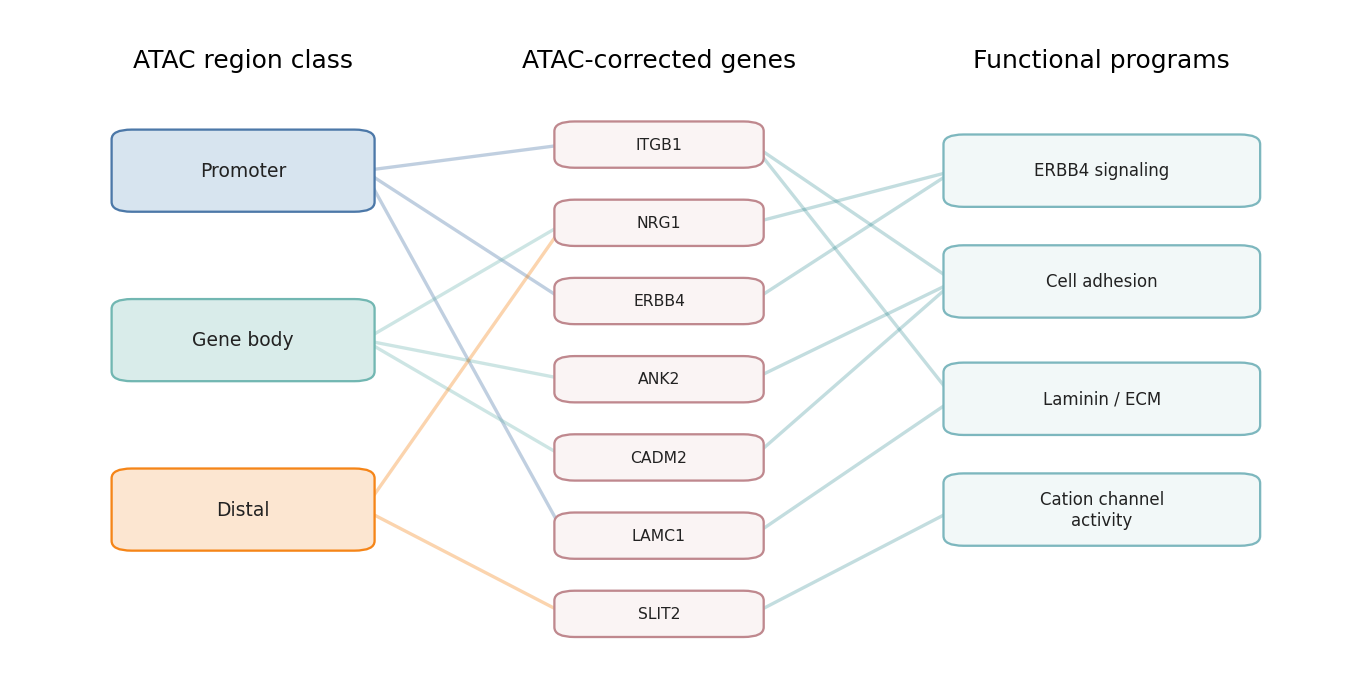

In [7]:
# Region-gene-program mechanism network

network_output_prefix = (
    OUTPUT_DIR
    / "smarca4_region_gene_program_network"
)

region_nodes = {
    "Promoter": (
        0.17,
        0.76,
    ),
    "Gene body": (
        0.17,
        0.50,
    ),
    "Distal": (
        0.17,
        0.24,
    ),
}

gene_nodes = {
    "ITGB1": (
        0.48,
        0.80,
    ),
    "NRG1": (
        0.48,
        0.68,
    ),
    "ERBB4": (
        0.48,
        0.56,
    ),
    "ANK2": (
        0.48,
        0.44,
    ),
    "CADM2": (
        0.48,
        0.32,
    ),
    "LAMC1": (
        0.48,
        0.20,
    ),
    "SLIT2": (
        0.48,
        0.08,
    ),
}

program_nodes = {
    "ERBB4 signaling": (
        0.81,
        0.76,
    ),
    "Cell adhesion": (
        0.81,
        0.59,
    ),
    "Laminin / ECM": (
        0.81,
        0.41,
    ),
    "Cation channel\nactivity": (
        0.81,
        0.24,
    ),
}

region_to_gene = {
    "Promoter": [
        "ITGB1",
        "ERBB4",
        "LAMC1",
    ],
    "Gene body": [
        "NRG1",
        "ANK2",
        "CADM2",
    ],
    "Distal": [
        "SLIT2",
        "NRG1",
    ],
}

gene_to_program = {
    "ITGB1": [
        "Cell adhesion",
        "Laminin / ECM",
    ],
    "NRG1": [
        "ERBB4 signaling",
    ],
    "ERBB4": [
        "ERBB4 signaling",
    ],
    "ANK2": [
        "Cell adhesion",
    ],
    "CADM2": [
        "Cell adhesion",
    ],
    "LAMC1": [
        "Laminin / ECM",
    ],
    "SLIT2": [
        "Cation channel\nactivity",
    ],
}

region_styles = {
    "Promoter": {
        "face": "#D7E4EF",
        "edge": REGION_COLORS[
            "promoter"
        ],
    },
    "Gene body": {
        "face": "#D9ECEA",
        "edge": REGION_COLORS[
            "gene_body"
        ],
    },
    "Distal": {
        "face": "#FCE6D1",
        "edge": REGION_COLORS[
            "distal"
        ],
    },
}


def add_network_box(
    axis,
    center,
    width,
    height,
    text,
    face_color,
    edge_color,
    font_size,
):
    x_value, y_value = center

    patch = FancyBboxPatch(
        (
            x_value - width / 2,
            y_value - height / 2,
        ),
        width,
        height,
        boxstyle=(
            "round,pad=0.008,"
            "rounding_size=0.015"
        ),
        facecolor=face_color,
        edgecolor=edge_color,
        linewidth=1.1,
        zorder=3,
    )

    axis.add_patch(patch)

    axis.text(
        x_value,
        y_value,
        text,
        ha="center",
        va="center",
        fontsize=font_size,
        color="#222222",
        zorder=4,
    )


def add_network_link(
    axis,
    start,
    end,
    color,
    alpha,
):
    axis.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-",
            connectionstyle="arc3,rad=0.0",
            color=color,
            linewidth=1.6,
            alpha=alpha,
            zorder=1,
        )
    )


figure, axis = plt.subplots(
    figsize=(9.2, 4.6)
)

axis.set_xlim(
    0,
    1,
)
axis.set_ylim(
    0,
    1,
)
axis.axis("off")

for region, position in (
    region_nodes.items()
):
    style = region_styles[region]

    add_network_box(
        axis,
        position,
        0.18,
        0.11,
        region,
        style["face"],
        style["edge"],
        9,
    )

for gene, position in (
    gene_nodes.items()
):
    add_network_box(
        axis,
        position,
        0.14,
        0.055,
        gene,
        "#FAF4F4",
        COLOR_PAIRS[
            "rose"
        ]["light"],
        7.5,
    )

for program, position in (
    program_nodes.items()
):
    add_network_box(
        axis,
        position,
        0.22,
        0.095,
        program,
        "#F2F8F8",
        COLOR_PAIRS[
            "teal"
        ]["light"],
        8,
    )

for region, linked_genes in (
    region_to_gene.items()
):
    for gene in linked_genes:
        add_network_link(
            axis,
            (
                region_nodes[region][0]
                + 0.09,
                region_nodes[region][1],
            ),
            (
                gene_nodes[gene][0]
                - 0.07,
                gene_nodes[gene][1],
            ),
            region_styles[region][
                "edge"
            ],
            0.35,
        )

for gene, linked_programs in (
    gene_to_program.items()
):
    for program in linked_programs:
        add_network_link(
            axis,
            (
                gene_nodes[gene][0]
                + 0.07,
                gene_nodes[gene][1],
            ),
            (
                program_nodes[
                    program
                ][0]
                - 0.11,
                program_nodes[
                    program
                ][1],
            ),
            COLOR_PAIRS[
                "teal"
            ]["dark"],
            0.25,
        )

axis.text(
    0.17,
    0.93,
    "ATAC region class",
    ha="center",
    va="center",
    fontsize=12,
)
axis.text(
    0.48,
    0.93,
    "ATAC-corrected genes",
    ha="center",
    va="center",
    fontsize=12,
)
axis.text(
    0.81,
    0.93,
    "Functional programs",
    ha="center",
    va="center",
    fontsize=12,
)

figure.tight_layout()

save_figure(
    figure,
    network_output_prefix,
)

plt.show()


Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/atac_guidance_strength_ablation.png
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/atac_guidance_strength_ablation.svg
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/atac_guidance_strength_ablation.pdf


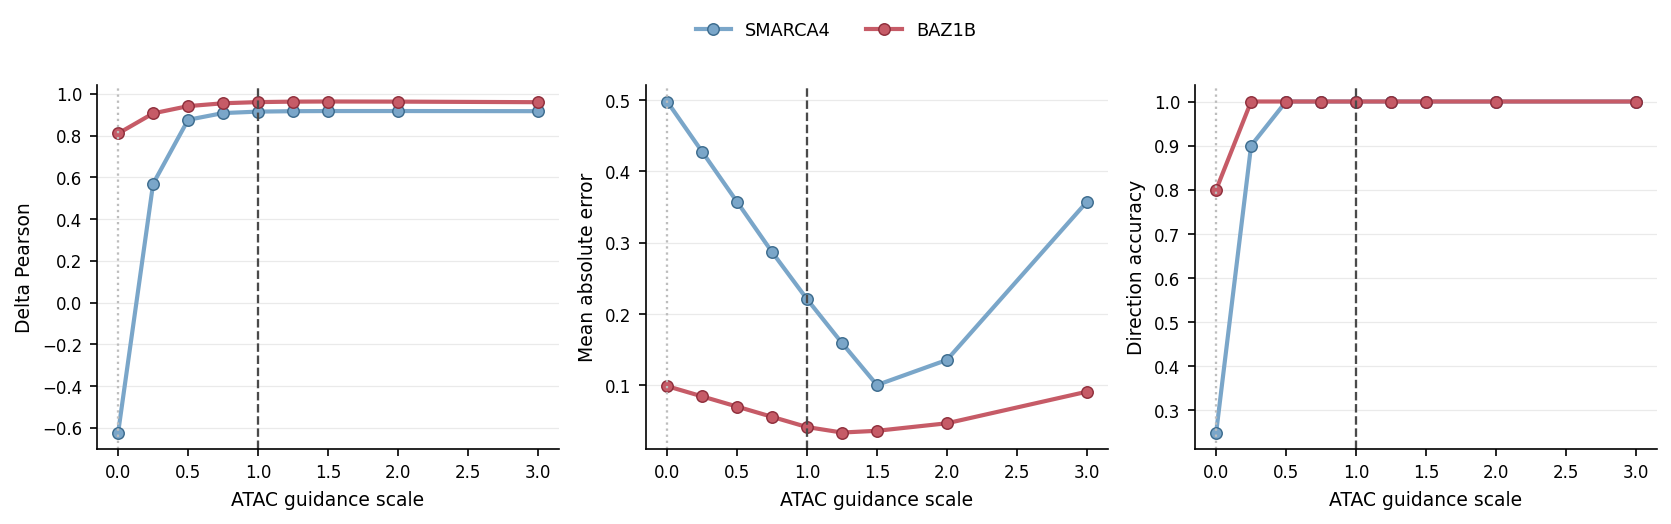

In [8]:
# ATAC guidance-strength ablation

guidance_path = require_file(
    BASE_DIR
    / "atac_guidance_strength_ablation"
    / "ATAC_guidance_strength_ablation_metrics.csv"
)

guidance_metrics = pd.read_csv(
    guidance_path
)

require_columns(
    guidance_metrics,
    [
        "perturbation",
        "top_k",
        "guidance_scale",
        "delta_pearson",
        "mae",
        "direction_accuracy",
    ],
    "ATAC guidance-strength table",
)

guidance_top20 = guidance_metrics[
    guidance_metrics["top_k"] == 20
].copy()

case_colors = {
    "SMARCA4": PAPER_COLORS["blue"],
    "BAZ1B": PAPER_COLORS["red"],
}

case_edge_colors = {
    "SMARCA4": "#3D6C8E",
    "BAZ1B": "#8F2F3C",
}

metric_specs = [
    (
        "delta_pearson",
        "Delta Pearson",
    ),
    (
        "mae",
        "Mean absolute error",
    ),
    (
        "direction_accuracy",
        "Direction accuracy",
    ),
]

figure, axes = plt.subplots(
    1,
    3,
    figsize=(11.2, 3.35),
)

for axis, (
    metric_column,
    y_label,
) in zip(
    axes,
    metric_specs,
):
    for case in [
        "SMARCA4",
        "BAZ1B",
    ]:
        case_data = (
            guidance_top20[
                guidance_top20[
                    "perturbation"
                ]
                == case
            ]
            .sort_values(
                "guidance_scale"
            )
        )

        axis.plot(
            case_data[
                "guidance_scale"
            ],
            case_data[
                metric_column
            ],
            color=case_colors[case],
            linewidth=2.0,
            marker="o",
            markersize=5.5,
            markeredgecolor=(
                case_edge_colors[case]
            ),
            markeredgewidth=0.7,
            label=case,
        )

    axis.axvline(
        0,
        linestyle=":",
        color=PAPER_COLORS["gray"],
        linewidth=1.1,
    )
    axis.axvline(
        1,
        linestyle="--",
        color=PAPER_COLORS["dark"],
        linewidth=1.1,
    )
    axis.set_xlabel(
        "ATAC guidance scale"
    )
    axis.set_ylabel(y_label)
    axis.grid(
        axis="y",
        color="#EAEAEA",
        linewidth=0.6,
    )

handles, labels = (
    axes[0].get_legend_handles_labels()
)

figure.legend(
    handles,
    labels,
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
)

figure.tight_layout(
    rect=[0, 0, 1, 0.92]
)

save_figure(
    figure,
    OUTPUT_DIR
    / "atac_guidance_strength_ablation",
)

plt.show()


Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/smarca4_peak_level_attribution.png
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/smarca4_peak_level_attribution.svg
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/smarca4_peak_level_attribution.pdf


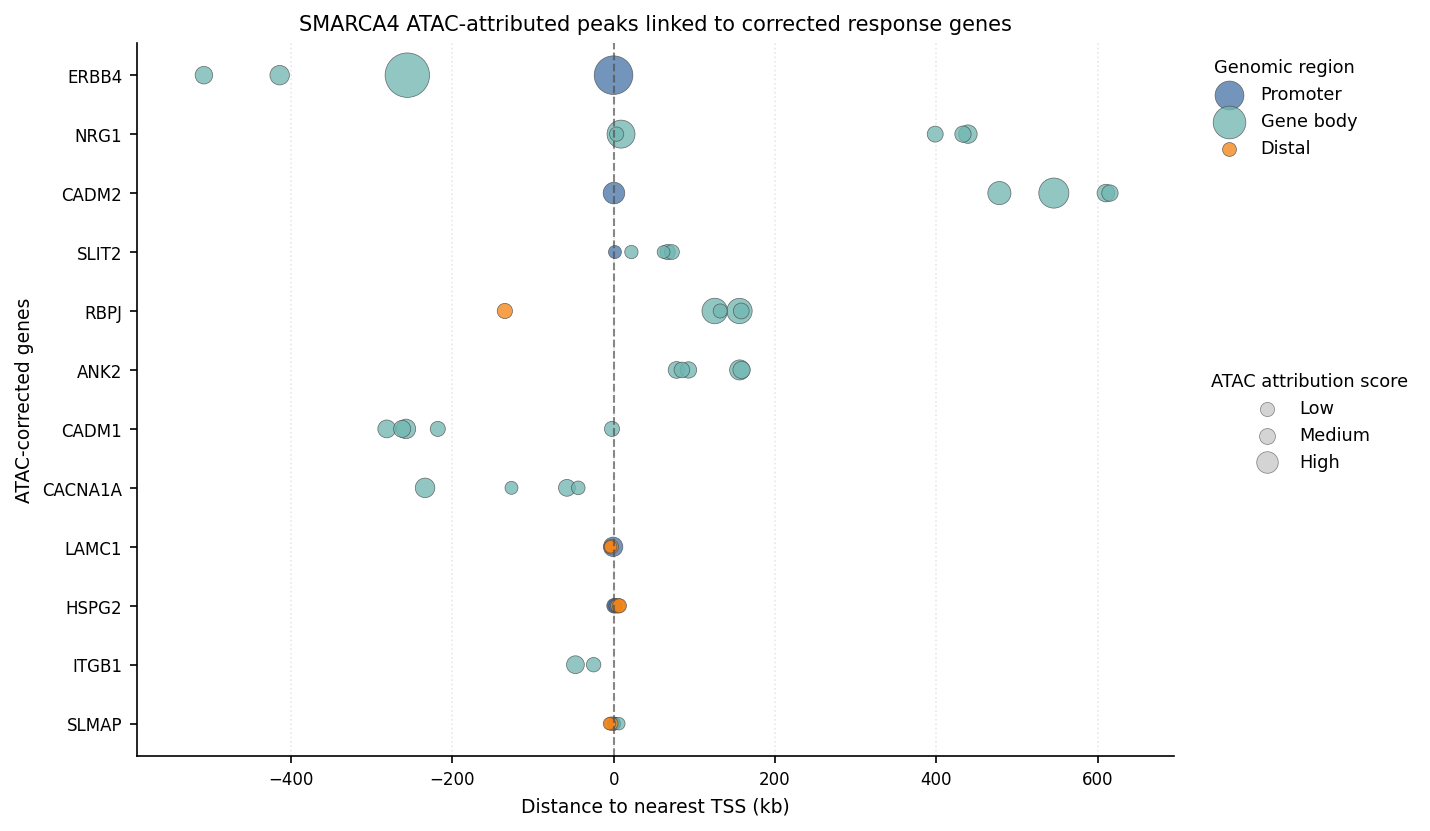

In [9]:
# Fine-grained peak-level attribution

peak_attribution_dir = (
    BASE_DIR
    / "smarca4_finegrained_peak_level_attribution"
)

top_peaks_path = require_file(
    peak_attribution_dir
    / "SMARCA4_top5_peaks_per_core_corrected_gene.csv"
)

top_peaks = pd.read_csv(
    top_peaks_path
)

require_columns(
    top_peaks,
    [
        "peak",
        "nearest_gene",
        "region_class",
        "distance_to_tss",
        "peak_abs_score",
    ],
    "Fine-grained peak attribution table",
)

core_genes = [
    "ERBB4",
    "NRG1",
    "CADM2",
    "SLIT2",
    "RBPJ",
    "ANK2",
    "CADM1",
    "CACNA1A",
    "LAMC1",
    "HSPG2",
    "ITGB1",
    "SLMAP",
]

peak_plot_data = top_peaks[
    top_peaks[
        "nearest_gene"
    ].isin(core_genes)
    & top_peaks[
        "region_class"
    ].isin(REGION_ORDER)
].copy()

if peak_plot_data.empty:
    raise ValueError(
        "No rows remain after filtering "
        "the fine-grained peak table."
    )

gene_order = [
    gene
    for gene in core_genes
    if gene
    in set(
        peak_plot_data[
            "nearest_gene"
        ]
    )
]

gene_positions = {
    gene: index
    for index, gene in enumerate(
        gene_order
    )
}

peak_plot_data["gene_y"] = (
    peak_plot_data[
        "nearest_gene"
    ].map(gene_positions)
)

peak_plot_data[
    "distance_to_tss_kb"
] = (
    pd.to_numeric(
        peak_plot_data[
            "distance_to_tss"
        ],
        errors="coerce",
    )
    / 1000.0
)

peak_plot_data[
    "peak_abs_score"
] = pd.to_numeric(
    peak_plot_data[
        "peak_abs_score"
    ],
    errors="coerce",
)

peak_plot_data = (
    peak_plot_data
    .dropna(
        subset=[
            "distance_to_tss_kb",
            "peak_abs_score",
            "gene_y",
        ]
    )
    .copy()
)

scores = peak_plot_data[
    "peak_abs_score"
].astype(float)

score_min = float(
    scores.min()
)
score_max = float(
    scores.max()
)


def peak_score_to_size(value):
    if score_max > score_min:
        return (
            35.0
            + 420.0
            * (
                (
                    float(value)
                    - score_min
                )
                / (
                    score_max
                    - score_min
                )
            )
        )

    return 120.0


peak_plot_data[
    "point_size"
] = scores.map(
    peak_score_to_size
)

x_low = float(
    peak_plot_data[
        "distance_to_tss_kb"
    ].quantile(0.02)
)
x_high = float(
    peak_plot_data[
        "distance_to_tss_kb"
    ].quantile(0.98)
)
x_padding = max(
    50.0,
    0.08 * (
        x_high - x_low
    ),
)

figure, axis = plt.subplots(
    figsize=(
        9.6,
        max(
            5.6,
            0.46 * len(gene_order),
        ),
    )
)

for region in REGION_ORDER:
    region_data = peak_plot_data[
        peak_plot_data[
            "region_class"
        ]
        == region
    ]

    if region_data.empty:
        continue

    axis.scatter(
        region_data[
            "distance_to_tss_kb"
        ],
        region_data["gene_y"],
        s=region_data[
            "point_size"
        ],
        color=REGION_COLORS[
            region
        ],
        alpha=0.78,
        edgecolor=PAPER_COLORS[
            "dark"
        ],
        linewidth=0.35,
        label=REGION_LABELS[
            region
        ],
        rasterized=True,
    )

axis.axvline(
    0,
    linestyle="--",
    color=PAPER_COLORS["dark"],
    linewidth=1.0,
    alpha=0.65,
)

axis.set_yticks(
    np.arange(
        len(gene_order)
    )
)
axis.set_yticklabels(
    gene_order
)
axis.invert_yaxis()

axis.set_xlim(
    x_low - x_padding,
    x_high + x_padding,
)
axis.set_xlabel(
    "Distance to nearest TSS (kb)"
)
axis.set_ylabel(
    "ATAC-corrected genes"
)
axis.set_title(
    "SMARCA4 ATAC-attributed peaks linked to corrected response genes"
)
axis.grid(
    axis="x",
    linestyle=":",
    alpha=0.30,
)

region_legend = axis.legend(
    title="Genomic region",
    frameon=False,
    bbox_to_anchor=(
        1.02,
        1.0,
    ),
    loc="upper left",
)

axis.add_artist(
    region_legend
)

score_quantiles = scores.quantile(
    [
        0.25,
        0.50,
        0.85,
    ]
).to_numpy()

score_handles = [
    axis.scatter(
        [],
        [],
        s=peak_score_to_size(
            score_value
        ),
        color=PAPER_COLORS[
            "gray"
        ],
        alpha=0.65,
        edgecolor=PAPER_COLORS[
            "dark"
        ],
        linewidth=0.35,
        label=label,
    )
    for score_value, label in zip(
        score_quantiles,
        [
            "Low",
            "Medium",
            "High",
        ],
    )
]

axis.legend(
    handles=score_handles,
    title="ATAC attribution score",
    frameon=False,
    bbox_to_anchor=(
        1.02,
        0.56,
    ),
    loc="upper left",
)

figure.tight_layout()

save_figure(
    figure,
    OUTPUT_DIR
    / "smarca4_peak_level_attribution",
)

plt.show()


Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/method_comparison.png
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/method_comparison.svg
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/method_comparison.pdf


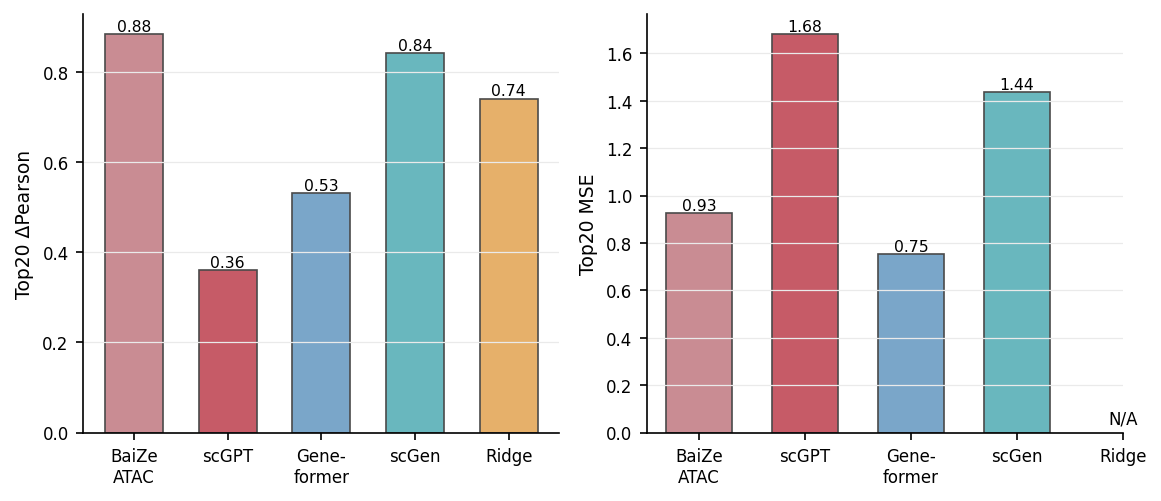

In [10]:
# Method comparison

method_names = [
    "BaiZe\nATAC",
    "scGPT",
    "Gene-\nformer",
    "scGen",
    "Ridge",
]

method_colors = [
    PAPER_COLORS["rose"],
    PAPER_COLORS["red"],
    PAPER_COLORS["blue"],
    PAPER_COLORS["teal"],
    PAPER_COLORS["orange"],
]

method_metrics = {
    "Top20 ΔPearson": [
        0.8836,
        0.3602,
        0.5303,
        0.8420,
        0.7404,
    ],
    "Top20 MSE": [
        0.9266,
        1.6815,
        0.7541,
        1.4380,
        np.nan,
    ],
}

figure, axes = plt.subplots(
    1,
    2,
    figsize=(7.8, 3.4),
)

for axis, (
    metric_name,
    metric_values,
) in zip(
    axes,
    method_metrics.items(),
):
    for index, value in enumerate(
        metric_values
    ):
        if np.isfinite(value):
            axis.bar(
                index,
                value,
                width=0.62,
                color=method_colors[
                    index
                ],
                edgecolor=PAPER_COLORS[
                    "dark"
                ],
                linewidth=0.8,
            )
            axis.text(
                index,
                value,
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=7.5,
            )
        else:
            axis.text(
                index,
                0.02,
                "N/A",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    axis.set_xticks(
        np.arange(
            len(method_names)
        )
    )
    axis.set_xticklabels(
        method_names
    )
    axis.set_ylabel(
        metric_name
    )
    axis.grid(
        axis="y",
        color="#EAEAEA",
        linewidth=0.6,
    )

figure.tight_layout()

save_figure(
    figure,
    OUTPUT_DIR
    / "method_comparison",
)

plt.show()


Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/rna_vs_atac_metrics.png
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/rna_vs_atac_metrics.svg
Saved figure: /root/autodl-tmp/scERso/multiperturb_seq/atac_functional_attribution_GRCh38/figures_deduplicated_runnable/rna_vs_atac_metrics.pdf


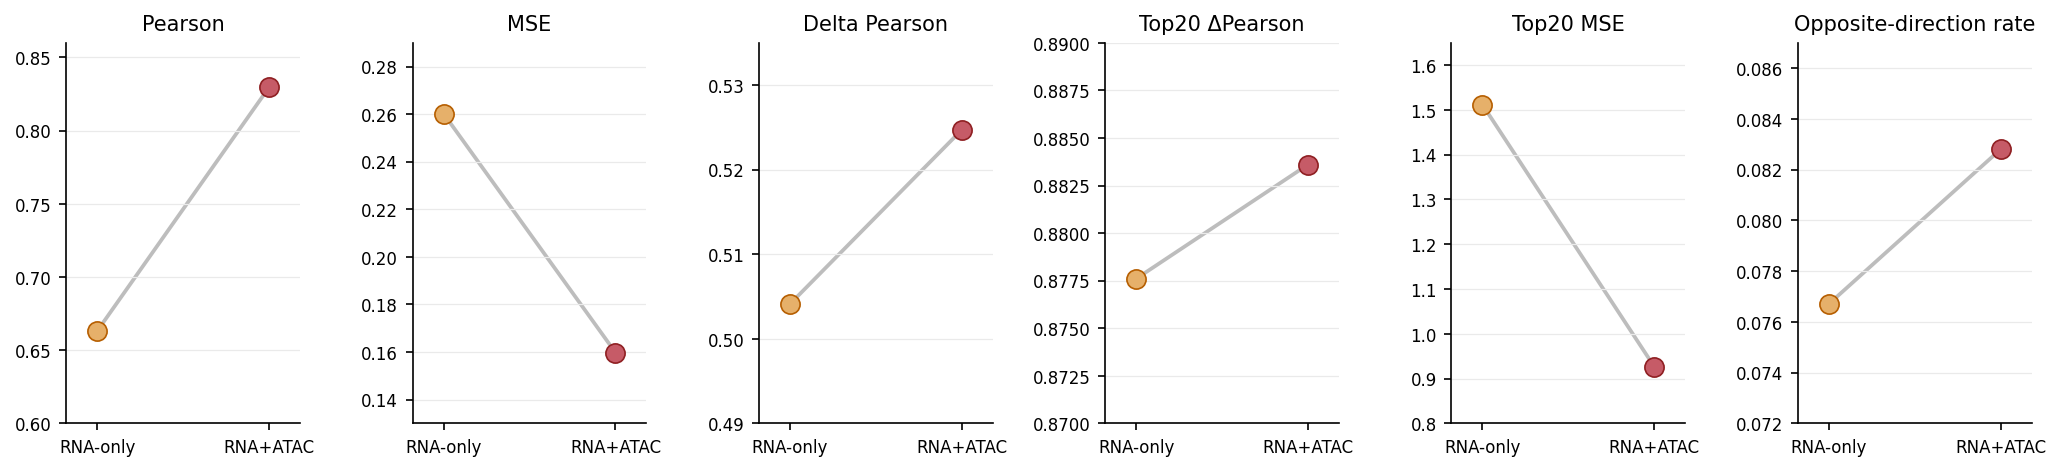

In [11]:
# RNA-only versus RNA+ATAC comparison

paired_metric_specs = [
    {
        "title": "Pearson",
        "values": [
            0.6632,
            0.8297,
        ],
        "ylim": (
            0.60,
            0.86,
        ),
    },
    {
        "title": "MSE",
        "values": [
            0.2602,
            0.1598,
        ],
        "ylim": (
            0.13,
            0.29,
        ),
    },
    {
        "title": "Delta Pearson",
        "values": [
            0.5041,
            0.5247,
        ],
        "ylim": (
            0.49,
            0.535,
        ),
    },
    {
        "title": "Top20 ΔPearson",
        "values": [
            0.8776,
            0.8836,
        ],
        "ylim": (
            0.870,
            0.890,
        ),
    },
    {
        "title": "Top20 MSE",
        "values": [
            1.5119,
            0.9266,
        ],
        "ylim": (
            0.80,
            1.65,
        ),
    },
    {
        "title": "Opposite-direction rate",
        "values": [
            0.0767,
            0.0828,
        ],
        "ylim": (
            0.072,
            0.087,
        ),
    },
]

rna_color = PAPER_COLORS[
    "orange"
]
atac_color = PAPER_COLORS[
    "red"
]

figure, axes = plt.subplots(
    1,
    len(paired_metric_specs),
    figsize=(13.8, 3.2),
)

for axis, metric_spec in zip(
    axes,
    paired_metric_specs,
):
    values = np.asarray(
        metric_spec["values"],
        dtype=float,
    )

    axis.plot(
        [
            0,
            1,
        ],
        values,
        color=PAPER_COLORS[
            "gray"
        ],
        linewidth=1.8,
        zorder=1,
    )

    axis.scatter(
        0,
        values[0],
        s=85,
        color=rna_color,
        edgecolor="#B65E00",
        linewidth=0.8,
        zorder=2,
    )

    axis.scatter(
        1,
        values[1],
        s=85,
        color=atac_color,
        edgecolor="#8F1F22",
        linewidth=0.8,
        zorder=2,
    )

    axis.set_xticks(
        [
            0,
            1,
        ]
    )
    axis.set_xticklabels(
        [
            "RNA-only",
            "RNA+ATAC",
        ]
    )
    axis.set_xlim(
        -0.18,
        1.18,
    )
    axis.set_ylim(
        metric_spec["ylim"]
    )
    axis.set_title(
        metric_spec["title"]
    )
    axis.grid(
        axis="y",
        color="#EAEAEA",
        linewidth=0.6,
    )

figure.tight_layout(
    w_pad=1.4
)

save_figure(
    figure,
    OUTPUT_DIR
    / "rna_vs_atac_metrics",
)

plt.show()
